In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(547, 1001, 3)


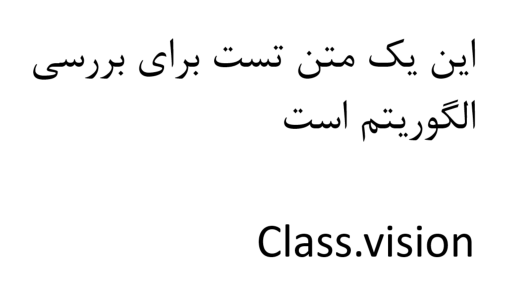

In [5]:
image = cv2.imread("/mnt/e/Image processing and computer vision using OpenCV/class.vision-master/images/matn.png")
print(image.shape)
plt.imshow(image[..., ::-1]); plt.axis("off");

(547, 1001, 3)


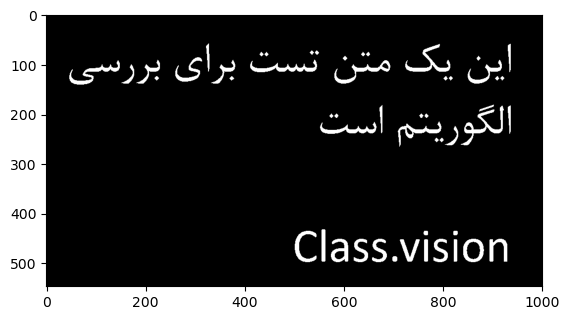

In [7]:
ret, thresh = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY_INV)
plt.imshow(thresh);
print(thresh.shape)

In [9]:
binary_image = cv2.cvtColor(thresh, cv2.COLOR_BGR2GRAY)
print(f"Shape of binary image: {binary_image.shape}")

Shape of binary image: (547, 1001)


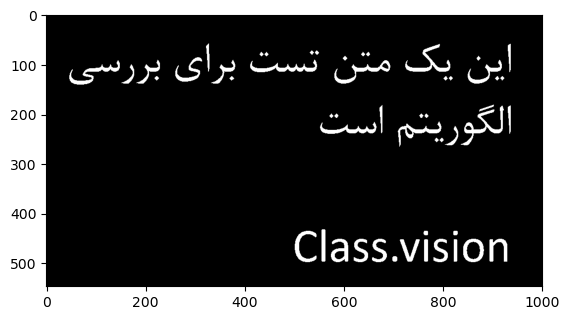

In [11]:
plt.imshow(binary_image, cmap='gray')

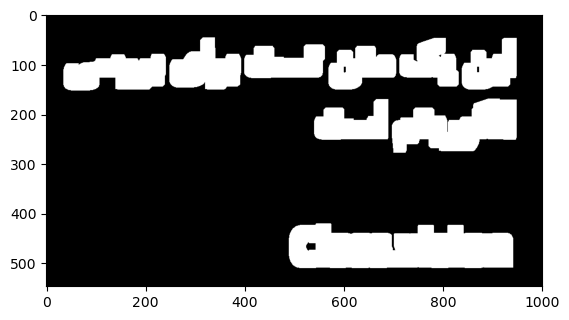

In [15]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 13))

dilated = cv2.dilate(binary_image, kernel=kernel, iterations=2)
plt.imshow(dilated, cmap='gray')

In [18]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
eroded = cv2.erode(dilated, kernel)

contours, hierarchy = cv2.findContours(eroded, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
print(len(contours))


13


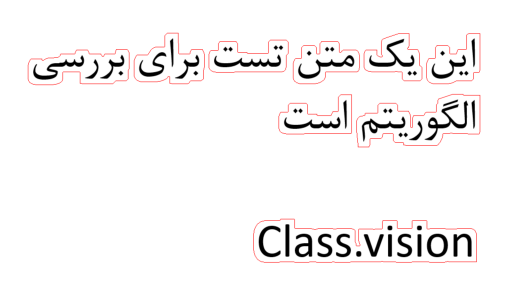

In [29]:
new_image = image.copy()

for contour in contours:
    if contour.shape[0] > 100:
        cv2.drawContours(new_image, [contour], 0, (0, 0, 255), 1)

plt.imshow(new_image[..., ::-1]); plt.axis('off');


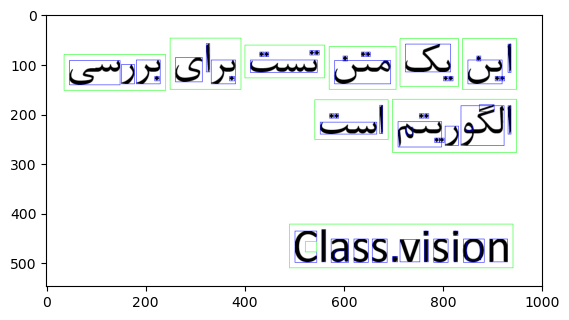

In [34]:
new_image = image.copy()

for contour in contours:
    if cv2.contourArea(contour) > 100:
        x, y, w, h = cv2.boundingRect(contour)

        roi = image[y:y+h, x:x+w]

        if len(roi.shape) == 3:
            roi = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

        _, roi = cv2.threshold(roi, 127, 255, cv2.THRESH_BINARY_INV)

        word_contours, _ = cv2.findContours(
            roi,
            cv2.RETR_TREE,
            cv2.CHAIN_APPROX_NONE
        )

        for word_contour in word_contours:
            x1, y1, w1, h1 = cv2.boundingRect(word_contour)

            cv2.rectangle(
                new_image,
                (x + x1, y + y1),
                (x + x1 + w1, y + y1 + h1),
                (0, 0, 255),
                1
            )

        cv2.rectangle(
            new_image,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            1
        )

plt.imshow(new_image)
plt.show()